In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Parameters
A0 = 1.0
B0 = 1.0
fc = 100e6        # carrier frequency
fa = 1e6          # message frequency
fs = 500e6        # sampling rate
T = 20e-7         # signal duration 

t = np.arange(0, T, 1/fs)

wa = 2*np.pi*fa
wc = 2*np.pi*fc
B = B0 * np.sin(wa*t)
transmitted_signal = A0 * np.sin(wc*t + B)

SNR before correlation: -0.05 dB
SNR after correlation: 10.84 dB


C:\Users\anunn\AppData\Local\Temp\ipykernel_7144\1969100058.py:35: RuntimeWarning: divide by zero encountered in log10
  plt.plot(lags, 20*np.log10(np.abs(corr)))


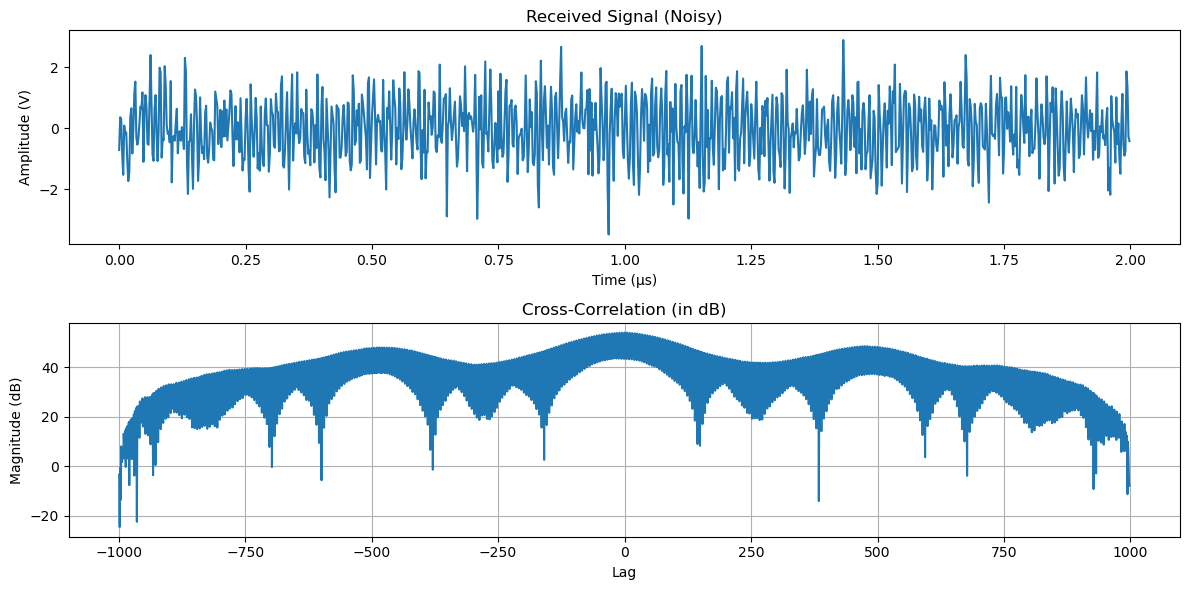

In [5]:
# ---------------- Add noise (simulate received signal) ----------------
SNR_dB_in = 0  # desired input SNR in dB
signal_power = np.mean(transmitted_signal**2)
noise_power = signal_power / (10**(SNR_dB_in/10))
noise = np.sqrt(noise_power) * np.random.randn(len(transmitted_signal))
received_signal = transmitted_signal + noise

# ---------------- Compute SNR before correlation ----------------
measured_noise = received_signal - transmitted_signal
SNR_before = 10 * np.log10(np.mean(transmitted_signal**2) / np.mean(measured_noise**2))
print(f"SNR before correlation: {SNR_before:.2f} dB")

# ---------------- Cross-correlation ----------------
corr = np.correlate(received_signal, transmitted_signal, mode='full')
lags = np.arange(-len(transmitted_signal)+1, len(transmitted_signal))

# ---------------- Compute SNR after correlation ----------------
# Take main correlation peak and side (noise) region
peak_power = np.max(np.abs(corr))**2
noise_region = np.delete(np.abs(corr)**2, np.argmax(np.abs(corr)))
noise_power_after = np.mean(noise_region)
SNR_after = 10 * np.log10(peak_power / noise_power_after)
print(f"SNR after correlation: {SNR_after:.2f} dB")

# ---------------- Plot ----------------
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(t*1e6, received_signal)
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude (V)")
plt.title("Received Signal (Noisy)")

plt.subplot(2,1,2)
plt.plot(lags, 20*np.log10(np.abs(corr)))
plt.title("Cross-Correlation (in dB)")
plt.xlabel("Lag")
plt.ylabel("Magnitude (dB)")
plt.grid(True)

plt.tight_layout()
plt.show()

SNR before correlation (receiver noise only): 118.97 dB
SNR after correlation: 10.86 dB


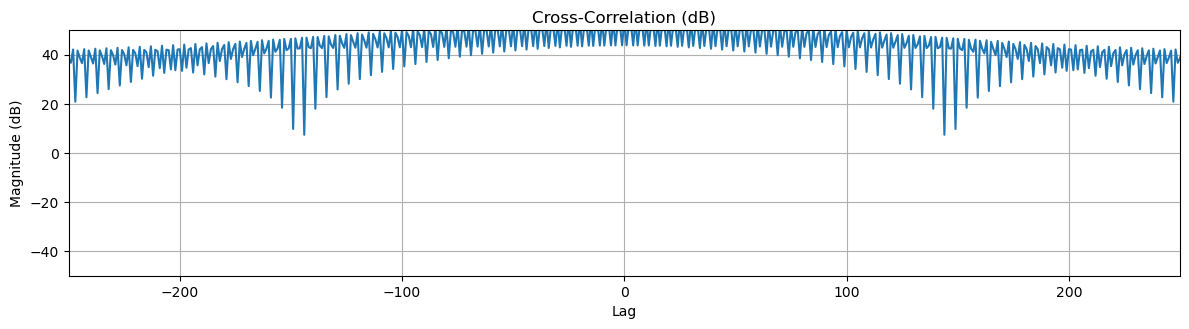

In [15]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# --- assumes these are already defined: transmitted_signal, fs, t ---
# transmitted_signal = ...
# fs = ...
# t = ...

# ---------------- Receiver thermal noise (only noise added) ----------------
k_B = 1.380649e-23     # Boltzmann constant (J/K)
T0 = 290.0             # reference temperature (K)

# Receiver params (edit as needed)
NF_dB = 5.0            # receiver Noise Figure in dB (typical 3-8 dB)
R_load = 50.0          # reference impedance (ohms). Set to 1.0 if your signals are normalized that way.
B = min(fs/2.0, 1e6)   # receiver bandwidth in Hz. Replace 1e6 with your actual filter bandwidth if known.

# Compute receiver noise power (watts) and convert to voltage variance
NF_linear = 10**(NF_dB/10)
noise_power_watts = k_B * T0 * B * NF_linear      # noise power (W) at input
noise_var_receiver = noise_power_watts * R_load   # V_rms^2 = P * R
noise_std_receiver = np.sqrt(noise_var_receiver)

# Generate receiver-only noise (Gaussian)
receiver_noise = noise_std_receiver * np.random.randn(len(transmitted_signal))

# Construct received signal: transmitted + receiver noise (no other noises)
received_signal = transmitted_signal + receiver_noise

# ---------------- Compute SNR before correlation ----------------
measured_noise = received_signal - transmitted_signal
SNR_before = 10 * np.log10(np.mean(transmitted_signal**2) / np.mean(measured_noise**2))
print(f"SNR before correlation (receiver noise only): {SNR_before:.2f} dB")

# ---------------- Cross-correlation and SNR after correlation ----------------
corr = np.correlate(received_signal, transmitted_signal, mode='full')
lags = np.arange(-len(transmitted_signal)+1, len(transmitted_signal))

peak_power = np.max(np.abs(corr))**2
noise_region = np.delete(np.abs(corr)**2, np.argmax(np.abs(corr)))
noise_power_after = np.mean(noise_region)
SNR_after = 10 * np.log10(peak_power / noise_power_after)
print(f"SNR after correlation: {SNR_after:.2f} dB")

# ---------------- Plots ----------------
plt.figure(figsize=(12,6))

plt.subplot(2,1,2)
plt.plot(lags, 20*np.log10(np.abs(corr) + 1e-12))
plt.title("Cross-Correlation (dB)")
plt.xlabel("Lag")
plt.ylabel("Magnitude (dB)")
plt.xlim(-250,250)
plt.ylim(-50,50)
plt.grid(True)
plt.tight_layout()
plt.show()
